# Эксперимент CatBoost

CatBoost хорошо работает с табличными данными и категориальными признаками без ручного OneHotEncoding

In [3]:
import hashlib
import json
import platform
import sys
from datetime import datetime
from pathlib import Path

import optuna
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42
ROOT_DIR = Path.cwd()
if ROOT_DIR.name == 'notebooks':
    ROOT_DIR = ROOT_DIR.parent

DATA_PATH = ROOT_DIR / 'data' / 'loan_data.csv'
ARTIFACT_DIR = ROOT_DIR / 'artifacts' / 'exp_catboost'
FIG_DIR = ARTIFACT_DIR / 'figures'
MODEL_DIR = ARTIFACT_DIR / 'models'
TRACKING_PATH = ARTIFACT_DIR / 'experiments.jsonl'

for path in [ARTIFACT_DIR, FIG_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)
plt.style.use('default')


def file_sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()


def load_data():
    df = pd.read_csv(DATA_PATH)
    target = 'loan_status'
    X = df.drop(columns=[target])
    y = df[target].astype(int)
    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
    return df, X, y, numeric_features, categorical_features


def append_jsonl(path: Path, row: dict):
    with path.open('a', encoding='utf-8') as f:
        f.write(json.dumps(row, ensure_ascii=False, default=str) + '\n')


def log_experiment(name: str, model_family: str, params: dict, val_metrics: dict, test_metrics: dict, artifacts: dict | None = None):
    row = {
        'run_id': hashlib.md5(f'{name}-{datetime.utcnow().isoformat()}'.encode()).hexdigest()[:12],
        'created_at': datetime.utcnow().isoformat(),
        'name': name,
        'model_family': model_family,
        'data_path': str(DATA_PATH.relative_to(ROOT_DIR)),
        'data_sha256': file_sha256(DATA_PATH),
        'python': sys.version.split()[0],
        'platform': platform.platform(),
        'target': 'loan_status',
        'params': params,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'artifacts': artifacts or {},
    }
    append_jsonl(TRACKING_PATH, row)
    return row


from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split


def make_splits(X, y):
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_val
    )
    return X_train, X_val, X_test, y_train, y_val, y_test, X_train_val, y_train_val


def predict_scores(model, X_data):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)[:, 1]
    return model.predict(X_data)


def compute_metrics(model, X_data, y_true) -> dict[str, float]:
    y_pred = model.predict(X_data)
    y_score = predict_scores(model, X_data)
    return {
        'roc_auc': float(roc_auc_score(y_true, y_score)),
        'average_precision': float(average_precision_score(y_true, y_score)),
        'f1': float(f1_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
    }

from catboost import CatBoostClassifier, Pool

In [4]:
df, X, y, numeric_features, categorical_features = load_data()
X_train, X_val, X_test, y_train, y_val, y_test, X_train_val, y_train_val = make_splits(X, y)
cat_features = categorical_features
print('cat_features:', cat_features)
print('train/val/test:', X_train.shape, X_val.shape, X_test.shape)

cat_features: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
train/val/test: (27000, 13) (9000, 13) (9000, 13)


In [7]:
def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 200, 1000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
    }

    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        **params,
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    val_metrics = compute_metrics(model, X_val, y_val)

    # Optuna maximizes
    return val_metrics["roc_auc"] if isinstance(val_metrics, dict) else val_metrics


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

best_params = study.best_params
print("Best params:", best_params)

[I 2026-05-16 18:25:45,663] A new study created in memory with name: no-name-00642ad7-653f-47f6-917a-cb9f092faf5c
[I 2026-05-16 18:25:49,928] Trial 0 finished with value: 0.9741834285714286 and parameters: {'iterations': 655, 'depth': 7, 'learning_rate': 0.03803512319935786, 'l2_leaf_reg': 5.4797050445287905}. Best is trial 0 with value: 0.9741834285714286.
[I 2026-05-16 18:25:52,351] Trial 1 finished with value: 0.9586025 and parameters: {'iterations': 439, 'depth': 6, 'learning_rate': 0.0011835553434432428, 'l2_leaf_reg': 7.775872852870748}. Best is trial 0 with value: 0.9741834285714286.
[I 2026-05-16 18:25:54,160] Trial 2 finished with value: 0.9656134285714286 and parameters: {'iterations': 223, 'depth': 8, 'learning_rate': 0.004342873595503558, 'l2_leaf_reg': 2.622599545574761}. Best is trial 0 with value: 0.9741834285714286.
[I 2026-05-16 18:26:03,511] Trial 3 finished with value: 0.9667537857142857 and parameters: {'iterations': 708, 'depth': 10, 'learning_rate': 0.001094320031

Best params: {'iterations': 997, 'depth': 8, 'learning_rate': 0.10736082489080703, 'l2_leaf_reg': 8.339912909223575}


NameError: name 'model_path' is not defined

In [8]:
model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        **best_params,
    )

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True,
)
model_path = MODEL_DIR / 'catboost_final.cbm'
model.save_model(model_path)

val_metrics = compute_metrics(model, X_val, y_val)
test_metrics = compute_metrics(model, X_test, y_test)

log_experiment(
    name='catboost_optuna_final',
    model_family='catboost',
    params=best_params,
    val_metrics=val_metrics,
    test_metrics=test_metrics,
    artifacts={'model': str(model_path.relative_to(ROOT_DIR))},
)

print('validation:', val_metrics)
print('test:', test_metrics)

validation: {'roc_auc': 0.9760425, 'average_precision': 0.9339819223181206, 'f1': 0.8366428382314006, 'precision': 0.8891389983117614, 'recall': 0.79, 'accuracy': 0.9314444444444444, 'balanced_accuracy': 0.8809285714285715}
test: {'roc_auc': 0.9773775000000001, 'average_precision': 0.9380615871936845, 'f1': 0.8483101912496726, 'precision': 0.8910291689598239, 'recall': 0.8095, 'accuracy': 0.9356666666666666, 'balanced_accuracy': 0.8906071428571429}


/var/folders/r2/wy5cx1bj3hd5n3q1hwfbtq6r0000gn/T/ipykernel_13836/1362430507.py:58: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'run_id': hashlib.md5(f'{name}-{datetime.utcnow().isoformat()}'.encode()).hexdigest()[:12],
/var/folders/r2/wy5cx1bj3hd5n3q1hwfbtq6r0000gn/T/ipykernel_13836/1362430507.py:59: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'created_at': datetime.utcnow().isoformat(),


,feature,importance
12,previous_loan_defaults_on_file,50.439308
9,loan_percent_income,10.241240
3,person_income,8.544025
8,loan_int_rate,7.945756
5,person_home_ownership,5.635911
7,loan_intent,4.625812
11,credit_score,3.636746
6,loan_amnt,2.985148
0,person_age,1.762408
10,cb_person_cred_hist_length,1.484825


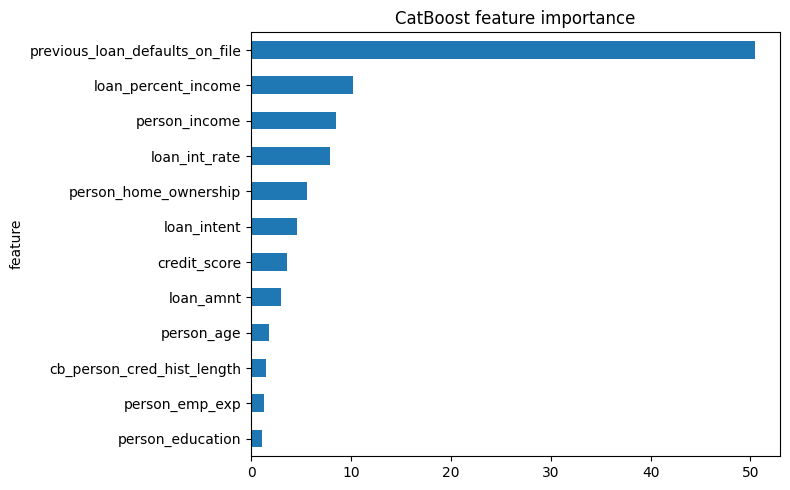

In [9]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.get_feature_importance(Pool(X_val, y_val, cat_features=cat_features)),
}).sort_values('importance', ascending=False)
display(importance)
importance.to_csv(ARTIFACT_DIR / 'catboost_feature_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
importance.head(12).iloc[::-1].plot(kind='barh', x='feature', y='importance', ax=ax, legend=False)
ax.set_title('CatBoost feature importance')
fig.tight_layout()
fig.savefig(FIG_DIR / 'catboost_feature_importance.png', dpi=150)
plt.show()